In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_pr = pd.read_csv('pr/pr_results.csv')

graph_info = {
    'soc-LiveJournal1.mtx': {'edges': 68993773, 'desc': 'Social (Power-law)'},
    'roadNet-CA.mtx': {'edges': 5533214, 'desc': 'Road (Low-degree)'},
    'rgg_n_2_22_s0.mtx': {'edges': 33554432, 'desc': 'Random (Regular)'}
}


df_clean = df_pr[~((df_pr['Library'] == 'SPLA') & (df_pr['Iters'] == 1))].copy()

df_stats = df_clean.groupby(['Graph', 'Library', 'Device'])['MS_per_Iter'].median().reset_index()

def calc_gteps(row):
    if row['Graph'] in graph_info:
        edges = graph_info[row['Graph']]['edges']
        return edges / (row['MS_per_Iter'] * 1e6)
    return 0

df_stats['GTEPS'] = df_stats.apply(calc_gteps, axis=1)
print(df_stats)

Empty DataFrame
Columns: [Graph, Library, Device, MS_per_Iter, GTEPS]
Index: []


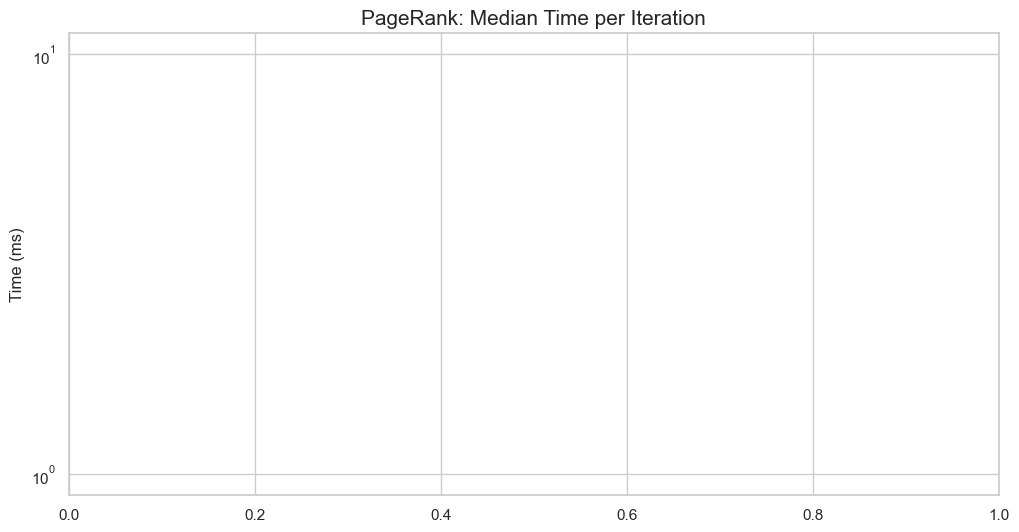

In [11]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_wstats, x='Graph', y='MS_per_Iter', hue='Library', palette='muted')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), textcoords = 'offset points', fontsize=10)

plt.title('PageRank: Median Time per Iteration', fontsize=15)
plt.ylabel('Time (ms)')
plt.yscale('log')
plt.show()

In [9]:
# Рассчитываем Speedup
pivot_df = df_stats.pivot(index='Graph', columns='Library', values='MS_per_Iter')
pivot_df['Speedup'] = pivot_df['LAGraph'] / pivot_df['SPLA']
pivot_df = pivot_df.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=pivot_df, x='Graph', y='Speedup', palette='magma')

plt.axhline(1.0, color='red', linestyle='--', label='Baseline (CPU)')
plt.title('Speedup of SPLA (GPU) over LAGraph (CPU)', fontsize=15)
plt.ylabel('Times faster (X)')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + 'x', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', fontsize=12, fontweight='bold')
plt.show()

KeyError: 'LAGraph'

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_stats, x='Graph', y='GTEPS', hue='Library', palette='viridis')

plt.title('Throughput Performance (GTEPS) - Higher is Better', fontsize=15)
plt.ylabel('Giga Edges per Second')
plt.show()